# Stage 3 - Optimize the futures hedge

**Input:** the forecast portfolio (`data/forecast_load.csv`), the completed HPFC
(`data/hpfc.csv`), and the same eligible futures used in Stage 2 (`data/selected_products.csv`,
COARSE_CAL and GRANULAR)

**Output:** the optimal futures position for each strategy (`data/hedge_positions.csv`) and the
resulting hedge energy per quarter-hour (`data/hedge_energy.csv`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
C_CAL, C_GRAN = "#DD8452", "#4C72B0"   # COARSE_CAL, GRANULAR
DT = 0.25   # quarter-hour, in hours

forecast = pd.read_csv(f"{DATA}/forecast_load.csv")
hpfc     = pd.read_csv(f"{DATA}/hpfc.csv")

df = forecast.merge(hpfc, on="timestamp_utc", validate="one_to_one")
df = df.rename(columns={"total": "L", "hpfc_eur_mwh": "HPFC"})[["timestamp_utc", "L", "HPFC", "period", "is_peak"]]
df["t_local"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")

print("merged grid:", df.shape, " -> forecast load (Stage 1) x HPFC (Stage 2), joined on timestamp_utc")
df.head()

merged grid: (35136, 6)  -> forecast load (Stage 1) x HPFC (Stage 2), joined on timestamp_utc


,timestamp_utc,L,HPFC,period,is_peak,t_local
0,2023-12-31T23:00:00Z,1.08,59.92,M01,0,2024-01-01 00:00:00+01:00
1,2023-12-31T23:15:00Z,1.00,59.92,M01,0,2024-01-01 00:15:00+01:00
2,2023-12-31T23:30:00Z,0.93,59.92,M01,0,2024-01-01 00:30:00+01:00
3,2023-12-31T23:45:00Z,0.87,59.92,M01,0,2024-01-01 00:45:00+01:00
4,2024-01-01T00:00:00Z,0.80,57.31,M01,0,2024-01-01 01:00:00+01:00


## 1. The hedge energy $H_t$

For each strategy we hold two positions per block $b$: $x_{base,b}$ and $x_{peak,b}$ MW. A Base
position delivers in *every* interval of its block; a Peak position delivers only in that block's
Peak intervals (Mon-Fri, 08:00-20:00, already flagged as `is_peak` in `hpfc.csv`). So the energy
the hedge delivers in quarter-hour $t$ (which belongs to exactly one block, since GRANULAR - and
trivially COARSE_CAL's single CAL block - tile the year) is:

$$H_t = \Delta t \cdot \big(x_{base,b(t)} + x_{peak,b(t)} \cdot \mathbb{1}[\text{is\_peak}_t]\big), \qquad \Delta t = 0.25\text{ h}$$

COARSE_CAL has one block (the whole year, "CAL"); GRANULAR reuses the six blocks from Stage 2
(M01, M02, M03, Q2, Q3, Q4). Because $H_t$ for $t$ in block $b$ only depends on that block's own
$x_{base,b}, x_{peak,b}$, every block can be sized **independently** of the others.

## 2. Value neutrality (the constraint)

Within each block $b$, the hedge must be worth exactly as much as the load it covers, when both
are priced at the HPFC we built in Stage 2:

$$\sum_{t \in b} H_t \cdot HPFC_t = \sum_{t \in b} L_t \cdot HPFC_t$$

This is one linear equation per block in the two unknowns $x_{base,b}, x_{peak,b}$: COARSE_CAL
gets a single annual constraint, GRANULAR gets six (one per block).

## 3. Minimize the shape mismatch (the objective)

Value neutrality alone leaves one free direction per block (2 unknowns, 1 equation) - a whole line
of positions all worth the same. Among that line, we pick the point that tracks the load's *shape*
best, i.e. that leaves the smallest quarter-hourly gaps:

$$\min_{x_{base,b},\, x_{peak,b}} \; \sum_{t \in b} (L_t - H_t)^2 \qquad \text{s.t. value neutrality and } x_{base,b}, x_{peak,b} \ge 0$$

This is a small **quadratic program** (convex, 2 variables, 1 equality constraint, 2 bounds) -
solved independently for every block. $x \ge 0$ rules out short futures positions: a retail
supplier hedges by buying forward to cover load it must deliver, not by selling power it doesn't
have.

In [2]:
def solve_block(sub):
    """Value-neutral, shape-minimizing (x_base, x_peak) >= 0 for one block."""
    L, P, ip = sub["L"].values, sub["HPFC"].values, sub["is_peak"].values.astype(float)
    S_all, S_peak, V_load = P.sum(), (P * ip).sum(), (L * P).sum()

    def objective(x):
        H = DT * (x[0] + x[1] * ip)
        return np.sum((L - H) ** 2)

    def objective_grad(x):
        H = DT * (x[0] + x[1] * ip)
        r = L - H
        return np.array([np.sum(-2 * DT * r), np.sum(-2 * DT * ip * r)])

    def value_gap(x):
        return DT * (x[0] * S_all + x[1] * S_peak) - V_load

    x0 = np.array([L.mean() / DT, 0.0])   # start at "all Base, no Peak"
    res = minimize(
        objective, x0, jac=objective_grad, method="SLSQP",
        constraints=[{"type": "eq", "fun": value_gap, "jac": lambda x: np.array([DT * S_all, DT * S_peak])}],
        bounds=[(0, None), (0, None)],
        options={"ftol": 1e-14, "maxiter": 500},
    )
    assert res.success, res.message
    x_base, x_peak = res.x
    H = DT * (x_base + x_peak * ip)
    return x_base, x_peak, H, value_gap(res.x)

In [3]:
strategies = {
    "COARSE_CAL": ["CAL"],
    "GRANULAR":   ["M01", "M02", "M03", "Q2", "Q3", "Q4"],
}

positions = []
for strategy, blocks in strategies.items():
    df[f"H_{strategy}"] = 0.0
    for block in blocks:
        rows = df.index if block == "CAL" else df.index[df["period"] == block]
        x_base, x_peak, H, err = solve_block(df.loc[rows])
        df.loc[rows, f"H_{strategy}"] = H
        positions.append({"strategy": strategy, "block": block,
                           "x_base_MW": x_base, "x_peak_MW": x_peak, "value_gap_EUR": err})

df["H_UNHEDGED"] = 0.0   # baseline: no futures at all, full exposure to Day-Ahead prices

positions = pd.DataFrame(positions)
assert np.allclose(positions["value_gap_EUR"], 0, atol=1e-6), "value neutrality violated somewhere"
assert (positions[["x_base_MW", "x_peak_MW"]] >= 0).all().all(), "a position went short"
print("all positions >= 0 (bound never binds); value neutrality holds in every block (max |gap| = "
      f"{positions['value_gap_EUR'].abs().max():.2e} EUR)")
positions

all positions >= 0 (bound never binds); value neutrality holds in every block (max |gap| = 0.00e+00 EUR)


,strategy,block,x_base_MW,x_peak_MW,value_gap_EUR
0,COARSE_CAL,CAL,4.39,1.88,0.00
1,GRANULAR,M01,5.04,2.33,0.00
2,GRANULAR,M02,4.93,2.22,0.00
3,GRANULAR,M03,4.65,1.97,0.00
4,GRANULAR,Q2,4.00,1.68,0.00
5,GRANULAR,Q3,3.85,1.54,0.00
6,GRANULAR,Q4,4.66,2.13,0.00


## 4. Check the hedge

For each strategy - including the **UNHEDGED** baseline ($x=0$ everywhere, i.e. no futures at
all) required by the project's strategy comparison - report: hedge notional energy vs. forecast
load, hedge value vs. load value (should match for the two optimized strategies - that is the
constraint), and two measures of the *shape* mismatch that value neutrality does **not** control:
the quarter-hourly RMSE and the total absolute residual volume $\sum_t |L_t - H_t|$ - the energy
that will still have to be bought or sold in the Day-Ahead market (Stage 4) because the hedge, at
only two levels per block, cannot follow the load's finer shape.

In [4]:
all_strategies = ["COARSE_CAL", "GRANULAR", "UNHEDGED"]

diag = pd.DataFrame({
    strategy: {
        "hedge_notional_MWh": df[f"H_{strategy}"].sum(),
        "load_MWh":           df["L"].sum(),
        "hedge_value_EUR":    (df[f"H_{strategy}"] * df["HPFC"]).sum(),
        "load_value_EUR":     (df["L"] * df["HPFC"]).sum(),
        "rmse_MWh_per_qh":    np.sqrt(np.mean((df["L"] - df[f"H_{strategy}"]) ** 2)),
        "residual_volume_MWh": np.sum(np.abs(df["L"] - df[f"H_{strategy}"])),
    }
    for strategy in all_strategies
}).T
diag["value_gap_EUR"] = diag["hedge_value_EUR"] - diag["load_value_EUR"]

# value neutrality is only a constraint for the two optimized strategies - UNHEDGED has zero
# hedge value by construction, so it is expected (and shown) to fail it completely.
assert np.allclose(diag.loc[["COARSE_CAL", "GRANULAR"], "value_gap_EUR"], 0, atol=1e-3)
diag

,hedge_notional_MWh,load_MWh,hedge_value_EUR,load_value_EUR,rmse_MWh_per_qh,residual_volume_MWh,value_gap_EUR
COARSE_CAL,"44,503.82","43,000.00","3,493,705.92","3,493,705.92",0.44,"12,760.13",-0.00
GRANULAR,"44,079.18","43,000.00","3,493,705.92","3,493,705.92",0.42,"11,985.15",-0.00
UNHEDGED,0.00,"43,000.00",0.00,"3,493,705.92",1.32,"43,000.00","-3,493,705.92"


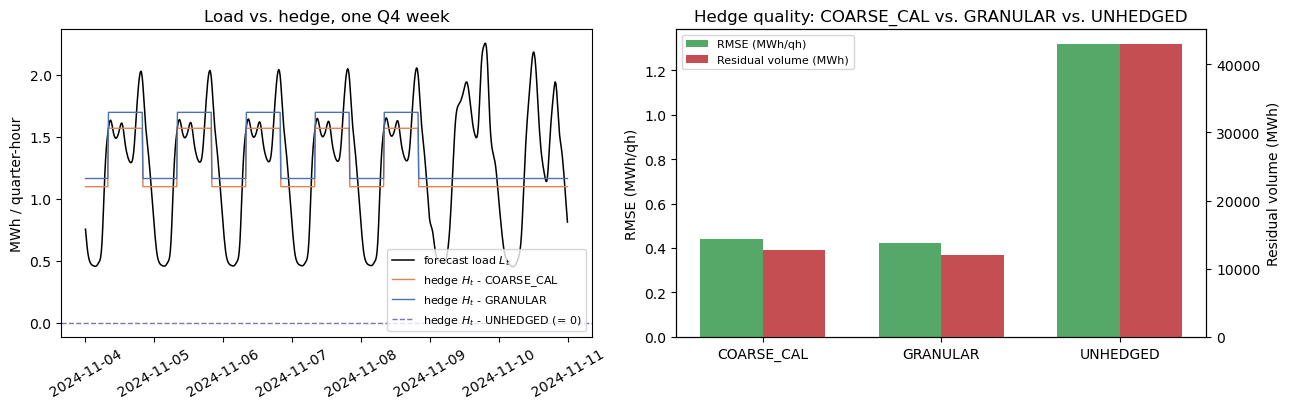

In [5]:
C_UNHEDGED = "#8172B3"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

s = pd.Timestamp("2024-11-04", tz="Europe/Berlin"); e = s + pd.Timedelta(days=7)
w = df[(df["t_local"] >= s) & (df["t_local"] < e)]
axes[0].plot(w["t_local"], w["L"], color="black", lw=1.1, label="forecast load $L_t$")
axes[0].plot(w["t_local"], w["H_COARSE_CAL"], color=C_CAL,  lw=1, label="hedge $H_t$ - COARSE_CAL")
axes[0].plot(w["t_local"], w["H_GRANULAR"],   color=C_GRAN, lw=1, label="hedge $H_t$ - GRANULAR")
axes[0].axhline(0, color=C_UNHEDGED, lw=1, ls="--", label="hedge $H_t$ - UNHEDGED (= 0)")
axes[0].set_title("Load vs. hedge, one Q4 week"); axes[0].set_ylabel("MWh / quarter-hour")
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=30)

x = np.arange(len(diag)); width = 0.35
ax2 = axes[1].twinx()
b1 = axes[1].bar(x - width / 2, diag["rmse_MWh_per_qh"], width, color="#55A868", label="RMSE (MWh/qh)")
b2 = ax2.bar(x + width / 2, diag["residual_volume_MWh"], width, color="#C44E52", label="Residual volume (MWh)")
axes[1].set_xticks(x); axes[1].set_xticklabels(diag.index)
axes[1].set_ylabel("RMSE (MWh/qh)"); ax2.set_ylabel("Residual volume (MWh)")
axes[1].set_title("Hedge quality: COARSE_CAL vs. GRANULAR vs. UNHEDGED")
axes[1].legend([b1, b2], [b1.get_label(), b2.get_label()], fontsize=8, loc="upper left")

plt.tight_layout(); plt.show()

**Comment.** GRANULAR's finer blocks bring a small but consistent improvement over COARSE_CAL
(RMSE 0.42 vs. 0.44 MWh/quarter-hour; residual volume 11,985 vs. 12,760 MWh/year, about 6% less).
The left panel shows why the gain is modest, not large: both hedges are still just a two-level step
function (a flat Base level, plus a flat Peak add-on across the whole 08-20 window) chasing a load
that has its own two humps *inside* the day (morning and evening) and a genuine weekday/weekend
swing - shape that no Base/Peak split can represent exactly, no matter how many blocks it is cut
into.

Both are nonetheless a large step up from **UNHEDGED**: with no futures at all, RMSE is 1.32
MWh/quarter-hour (3x GRANULAR's) and the residual volume is the full 43,000 MWh of forecast load -
every single MWh would have to be bought at whatever the Day-Ahead price turns out to be, with
zero of the year's value locked in today. Even the crude COARSE_CAL hedge already removes about
70% of that open volume.

## 5. Why value neutrality is not volume neutrality

Value neutrality is a **single price-weighted equation**: $\sum_t H_t \cdot HPFC_t = \sum_t L_t
\cdot HPFC_t$. It says the two sides balance once every quarter-hour is weighted by its price - it
says nothing about the two sides matching quarter-hour by quarter-hour, or even in total MWh.
Indeed, in the table above the hedge notional is *larger* than the forecast load for both
strategies (e.g. GRANULAR: 44,079 vs. 43,000 MWh - about 1,079 MWh more energy bought than
consumed) while the value gap is essentially zero: the optimizer is free to overshoot volume in
cheap (low-HPFC) quarter-hours - which barely moves the price-weighted sum - as long as it stays
tight in expensive ones, because that is what also shrinks the sum-of-squares objective. Volume
neutrality ($\sum_t H_t = \sum_t L_t$) would be a *different, additional* constraint; nothing here
enforces it.

**Risk remaining after optimization.**
- **Shape risk.** The residual volumes above (11,985-12,760 MWh/year, roughly 28% of annual load)
  must still be bought or sold in the Day-Ahead market - short when the hedge underdelivers
  against a demand spike, long when it overdelivers against a trough. This is exactly the exposure
  Stage 4/5 quantify.
- **Price risk on that residual.** Because the residual is settled at the *realised* Day-Ahead
  price rather than today's HPFC, and realised prices can depart sharply from the historical shape
  baked into the HPFC (Exhibit 3/4: cold snaps, low-wind days), the retailer is still exposed to
  price risk on every MWh the hedge does not physically cover - regardless of how well-valued the
  hedge is today.
- **Basis risk between HPFC and realised prices.** The HPFC was calibrated to a *historical*
  average shape (Stage 2); if 2024's actual Peak/Off-Peak or seasonal pattern shifts from that
  history, both the hedge's *value* (mismarked against the wrong curve) and its *shape fit* would
  be affected in ways this optimization cannot see in advance.

## 6. Save the hedge

In [6]:
positions_out = pd.concat([
    positions,
    pd.DataFrame([{"strategy": "UNHEDGED", "block": "-", "x_base_MW": 0.0, "x_peak_MW": 0.0,
                    "value_gap_EUR": diag.loc["UNHEDGED", "value_gap_EUR"]}]),
], ignore_index=True)
positions_out.to_csv(f"{DATA}/hedge_positions.csv", index=False)

energy = df[["timestamp_utc", "L", "H_COARSE_CAL", "H_GRANULAR", "H_UNHEDGED"]].rename(columns={
    "L": "load_mwh", "H_COARSE_CAL": "hedge_coarse_cal_mwh",
    "H_GRANULAR": "hedge_granular_mwh", "H_UNHEDGED": "hedge_unhedged_mwh",
})
energy.to_csv(f"{DATA}/hedge_energy.csv", index=False)

print("saved:", f"{DATA}/hedge_positions.csv", positions_out.shape)
print("saved:", f"{DATA}/hedge_energy.csv", energy.shape)
energy.head()

saved: ../data/hedge_positions.csv (8, 5)
saved: ../data/hedge_energy.csv (35136, 5)


,timestamp_utc,load_mwh,hedge_coarse_cal_mwh,hedge_granular_mwh,hedge_unhedged_mwh
0,2023-12-31T23:00:00Z,1.08,1.10,1.26,0.00
1,2023-12-31T23:15:00Z,1.00,1.10,1.26,0.00
2,2023-12-31T23:30:00Z,0.93,1.10,1.26,0.00
3,2023-12-31T23:45:00Z,0.87,1.10,1.26,0.00
4,2024-01-01T00:00:00Z,0.80,1.10,1.26,0.00
